In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_path = "trace_summary_combined.csv"

short_think_names = {
    'claude-sonnet-4-20250514-t1.0': 'CL-4',
    'claude-sonnet-4-20250514-t0.0': 'CL-4',
    'deepseek-r1-distill-llama-70b-t1.0':'LM-70B',
    'gpt-oss-120b-t1.0':'GPT-OSS',
    'nemotron-nano-9b-v2-t1.0':'Nem-9B',
    'qwen3-next-80b-a3b-thinking-t1.0':'Qwen-3'
}

def shorten_model_names(df):
    df['model'] = df['model'].map(short_think_names)
    return df

df = pd.read_csv(df_path)
trace_df = shorten_model_names(df)
trace_df.head()

,game_language,model,game,experiment,instance,author_role,agentive_persons,user_mentioned,player_count,loops,...,suspects_deception,intends_deception,main_score,response_rate,aborted,lose,success,thinking_length,response_length,ratio_thinking_response
0,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_hard,4,1.0,1.0,0.0,2.0,0.0,...,0.0,0.2,0.0,1.0,1,0,0,37880,1889,0.049868
1,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_hard,5,1.0,1.6,0.0,2.0,0.2,...,0.0,0.0,0.0,1.0,1,0,0,32160,715,0.022233
2,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_easy,4,1.0,1.0,0.6,2.0,0.2,...,0.0,0.0,0.0,1.0,1,0,0,30715,1607,0.052320
3,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_easy,5,1.0,0.8,0.6,1.8,0.2,...,0.0,0.0,0.0,1.0,1,0,0,32246,1053,0.032655
4,en,LM-70B,hot_air_balloon,air_balloon_survival_en_complexity_hard,3,0.4,1.6,0.6,2.0,0.2,...,0.0,0.2,0.0,1.0,1,0,0,14289,2410,0.168661


AttributeError: module 'matplotlib.cm' has no attribute 'set1'

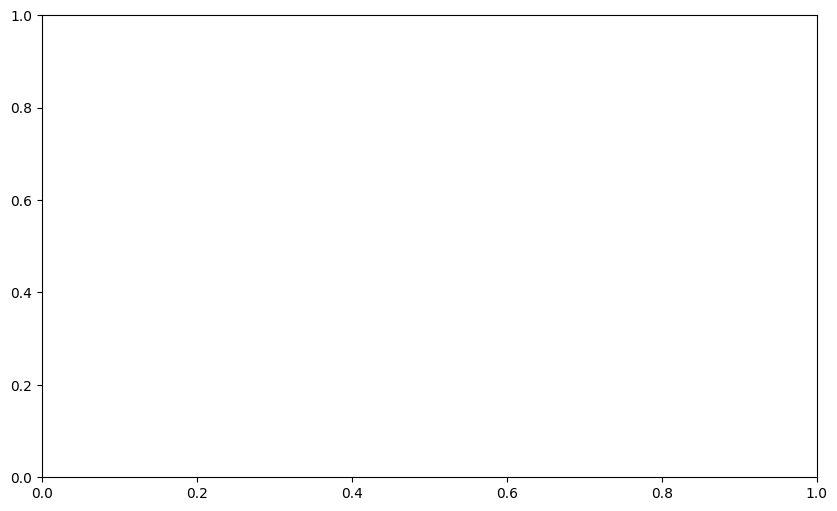

In [ ]:
models = trace_df['model'].unique()

# plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(figsize=(10, 6))
# scatter plot with different colors for each model
# x-axis: author_role, y-axis: main_score
for i, model in enumerate(models):
    # Overlay two scatter plots: one for individual points, one for averages. Use same color for both.
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    ax.scatter(model_df['author_role'], model_df['main_score'], label=model, alpha=0.5, color=color)
    main_score_mean = model_df['main_score'].mean()
    author_role_mean = model_df['author_role'].mean()
    ax.scatter(author_role_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', color=color, marker='X')

# find a line that separates 90% of the data points
ax.axhline(y=main_score_mean, color='r', linestyle='--', label='Mean Main Score')

ax.set_xlabel('Assumed Model Role: Assistant (0) vs Player (1)')
ax.set_ylabel('Main Score')
ax.set_title('Assumed Model Role vs Main Score')
ax.legend()
plt.show()